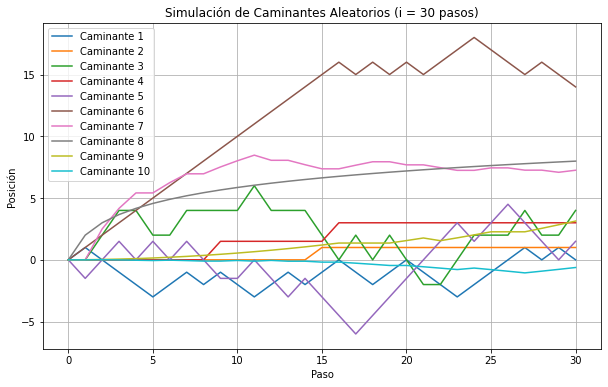

In [123]:
import random
import matplotlib.pyplot as plt

# Semilla opcional para reproducibilidad
# random.seed(42)

def p_q_r_constantes(p, q, r):
    """
    Devuelve funciones que ignoran i y retornan p, q, r constantes.
    """
    def p_func(i): return p
    def q_func(i): return q
    def r_func(i): return r
    return p_func, q_func, r_func

def p_q_r_dependientes_6():
    """
    Caso 6: p = min(1, 12/i), q = 1 - p, r = 1
    """
    def p_func(i):
        return min(1, 12/i)
    def q_func(i):
        return 1 - p_func(i)
    def r_func(i):
        return 1
    return p_func, q_func, r_func

def p_q_r_dependientes_7():
    """
    Caso 7: p = 0.5, q = 0.3, r = 5/i
    """
    def p_func(i):
        return 0.5
    def q_func(i):
        return 0.3
    def r_func(i):
        return 5/i
    return p_func, q_func, r_func

def p_q_r_dependientes_8():
    """
    Caso 8: p = 1, q = 0, r = 2/i
    """
    def p_func(i):
        return 1
    def q_func(i):
        return 0
    def r_func(i):
        return 2/i
    return p_func, q_func, r_func

def p_q_r_dependientes_9():
    """
    Caso 9: p = min(1, 10/i), q = min(1-p, 0.05), r = 0.01*i
    """
    def p_func(i):
        return min(1, 10/i)
    def q_func(i):
        # Primero calculamos p
        p_val = p_func(i)
        # q = min(1 - p, 0.05)
        return min(1 - p_val, 0.05)
    def r_func(i):
        return 0.01*i
    return p_func, q_func, r_func

def p_q_r_dependientes_10():
    """
    Caso 10: p = 0.45, q = 0.45, r = 0.005*i
    """
    def p_func(i):
        return 0.45
    def q_func(i):
        return 0.45
    def r_func(i):
        return 0.005*i
    return p_func, q_func, r_func

def simular_caminantes(num_pasos=30):
    """
    Simula los 10 caminantes con sus definiciones de p, q y r.
    Devuelve una lista de listas con las posiciones de cada caminante
    a lo largo de los pasos (índices 0..num_pasos).
    """
    # Definimos las funciones (p, q, r) para cada uno de los 10 casos
    caminantes_def = [
        # 1) p = 0.5,  q = 0.5,  r = 1
        p_q_r_constantes(0.5, 0.5, 1),
        # 2) p = 0.05, q = 0.01, r = 1
        p_q_r_constantes(0.05, 0.01, 1),
        # 3) p = 0.3,  q = 0.3,  r = 2
        p_q_r_constantes(0.3, 0.3, 2),
        # 4) p = 0.05, q = 0.02, r = 1.5
        p_q_r_constantes(0.05, 0.02, 1.5),
        # 5) p = 0.45, q = 0.44, r = 1.5
        p_q_r_constantes(0.45, 0.44, 1.5),
        # 6) p = min(1,12/i), q = 1-p, r = 1
        p_q_r_dependientes_6(),
        # 7) p = 0.5, q = 0.3, r = 5/i
        p_q_r_dependientes_7(),
        # 8) p = 1,   q = 0,   r = 2/i
        p_q_r_dependientes_8(),
        # 9) p = min(1,10/i), q = min(1-p,0.05), r = 0.01*i
        p_q_r_dependientes_9(),
        # 10) p = 0.45, q = 0.45, r = 0.005*i
        p_q_r_dependientes_10()
    ]

    num_caminantes = len(caminantes_def)
    # Inicializamos las posiciones en 0 para cada caminante
    # Guardamos posiciones en una matriz [caminante][paso]
    posiciones = [[0.0]*(num_pasos+1) for _ in range(num_caminantes)]

    # Para cada paso, actualizamos la posición de cada caminante
    for i in range(1, num_pasos+1):
        for idx, (p_func, q_func, r_func) in enumerate(caminantes_def):
            # Posición anterior
            pos_anterior = posiciones[idx][i-1]
            # Calculamos p, q, r en el paso i
            p = p_func(i)
            q = q_func(i)
            r = r_func(i)
            # Probabilidad de quedarse quieto
            stay = 1 - p - q
            # Aseguramos que no sea negativo (por si hay definiciones que excedan 1)
            if stay < 0:
                # Ajuste simple para evitar probabilidades negativas
                # (podrías manejarlo de otra forma, dependiendo de tu modelo)
                stay = 0
            
            # Generamos un número aleatorio para ver el movimiento
            u = random.random()
            if u < p:             # va a la derecha
                nueva_pos = pos_anterior + r
            elif u < p + q:      # va a la izquierda
                nueva_pos = pos_anterior - r
            else:                # se queda en la misma posición
                nueva_pos = pos_anterior
            
            posiciones[idx][i] = nueva_pos
    
    return posiciones

def main():
    # Simulamos 30 pasos
    num_pasos = 30
    posiciones = simular_caminantes(num_pasos)

    # Graficamos la trayectoria de cada caminante
    plt.figure(figsize=(10, 6))
    
    num_caminantes = len(posiciones)
    for idx in range(num_caminantes):
        plt.plot(range(num_pasos+1), posiciones[idx], label=f'Caminante {idx+1}')

    plt.title('Simulación de Caminantes Aleatorios (i = 30 pasos)')
    plt.xlabel('Paso')
    plt.ylabel('Posición')
    plt.legend()
    plt.grid(True)
    plt.show()

if __name__ == "__main__":
    main()


6 - 4 - 8

6 - 7 - 8

6 - 1 - 8

In [122]:
import numpy as np
import matplotlib.pyplot as plt

def random_walk(p_func, q_func, r_func, steps=30):
    position = 0
    for i in range(1, steps + 1):
        p = p_func(i)
        q = q_func(i)
        r = r_func(i)
        move = np.random.choice([-1, 0, 1], p=[q, 1 - (p + q), p])
        position += move * r
    return position

# Definimos las funciones para cada caso
def p1(i): return 0.5
def q1(i): return 0.5
def r1(i): return 1

def p2(i): return 0.05
def q2(i): return 0.01
def r2(i): return 1

def p3(i): return 0.3
def q3(i): return 0.3
def r3(i): return 2

def p4(i): return 0.05
def q4(i): return 0.02
def r4(i): return 1.5

def p5(i): return 0.45
def q5(i): return 0.44
def r5(i): return 1.5

def p6(i): return min(1, 12/i)
def q6(i): return 1 - p6(i)
def r6(i): return 1

def p7(i): return 0.5
def q7(i): return 0.3
def r7(i): return 5/i

def p8(i): return 1
def q8(i): return 0
def r8(i): return 2/i

def p9(i): return min(1, 10/i)
def q9(i): return min(1 - p9(i), 0.05)
def r9(i): return 0.01 * i

def p10(i): return 0.45
def q10(i): return 0.45
def r10(i): return 0.005 * i

# Lista de funciones de caminantes
walkers = [(p1, q1, r1), (p2, q2, r2), (p3, q3, r3), (p4, q4, r4), (p5, q5, r5),
           (p6, q6, r6), (p7, q7, r7), (p8, q8, r8), (p9, q9, r9), (p10, q10, r10)]

# Simulación de los caminantes
results = [random_walk(p, q, r) for p, q, r in walkers]

# Determinar el caminante que llegó más lejos
max_distance = max(results)
best_walker = results.index(max_distance) + 1

# Mostrar resultados
for i, res in enumerate(results, 1):
    print(f"Caminante {i}: distancia final = {res:.4f}")

print(f"El caminante que llegó más lejos es el {best_walker} con una distancia de {max_distance:.4f}")


Caminante 1: distancia final = 0.0000
Caminante 2: distancia final = 1.0000
Caminante 3: distancia final = 24.0000
Caminante 4: distancia final = 1.5000
Caminante 5: distancia final = 3.0000
Caminante 6: distancia final = 12.0000
Caminante 7: distancia final = 6.1599
Caminante 8: distancia final = 7.9900
Caminante 9: distancia final = 1.6100
Caminante 10: distancia final = 0.3950
El caminante que llegó más lejos es el 3 con una distancia de 24.0000


In [104]:
import random

def simulate_walk(p, q, r, steps):
    position = 0
    for i in range(1, steps + 1):
        # Ajustar p y q si dependen de i
        if callable(p):
            p_val = p(i)
        else:
            p_val = p
        
        if callable(q):
            q_val = q(i)
        else:
            q_val = q
        
        # Ajustar r si depende de i
        if callable(r):
            r_val = r(i)
        else:
            r_val = r
        
        # Generar un número aleatorio para decidir el movimiento
        rand = random.random()
        if rand < p_val:
            position += r_val  # Moverse a la derecha
        elif rand < p_val + q_val:
            position -= r_val  # Moverse a la izquierda
        # Si no, no se mueve (se queda en la misma posición)
    
    return position

# Definir los caminantes
walkers = [
    {"p": 0.5, "q": 0.5, "r": 1},
    {"p": 0.05, "q": 0.01, "r": 1},
    {"p": 0.3, "q": 0.3, "r": 2},
    {"p": 0.05, "q": 0.02, "r": 1.5},
    {"p": 0.45, "q": 0.44, "r": 1.5},
    {"p": lambda i: min(1, 12/i), "q": lambda i: 1 - min(1, 12/i), "r": 1},
    {"p": 0.5, "q": 0.3, "r": lambda i: 5/i},
    {"p": 1, "q": 0, "r": lambda i: 2/i},
    {"p": lambda i: min(1, 10/i), "q": lambda i: min(1 - min(1, 10/i), 0.05), "r": lambda i: 0.01*i},
    {"p": 0.45, "q": 0.45, "r": lambda i: 0.005*i}
]

# Simular cada caminante
steps = 30
results = []
for i, walker in enumerate(walkers):
    final_position = simulate_walk(walker["p"], walker["q"], walker["r"], steps)
    results.append((i + 1, final_position))
    print(f"Caminante {i + 1}: Posición final = {final_position}")

# Encontrar el caminante que llegó más lejos
max_walker = max(results, key=lambda x: abs(x[1]))
print(f"\nEl caminante que llegó más lejos es el Caminante {max_walker[0]} con una posición final de {max_walker[1]}.")

Caminante 1: Posición final = 2
Caminante 2: Posición final = 1
Caminante 3: Posición final = 4
Caminante 4: Posición final = -3.0
Caminante 5: Posición final = 7.5
Caminante 6: Posición final = 14
Caminante 7: Posición final = 5.690208640337736
Caminante 8: Posición final = 7.989974261840781
Caminante 9: Posición final = 2.34
Caminante 10: Posición final = -0.09499999999999997

El caminante que llegó más lejos es el Caminante 6 con una posición final de 14.


In [79]:
import numpy as np
import matplotlib.pyplot as plt

def random_walk(p_func, q_func, r_func, steps=30):
    position = 0
    for i in range(1, steps + 1):
        p = p_func(i)
        q = q_func(i)
        r = r_func(i)
        move = np.random.choice([-1, 0, 1], p=[q, 1 - (p + q), p])
        position += move * r
    return position

# Definimos las funciones para cada caso
def p1(i): return 0.5
def q1(i): return 0.5
def r1(i): return 1

def p2(i): return 0.05
def q2(i): return 0.01
def r2(i): return 1

def p3(i): return 0.3
def q3(i): return 0.3
def r3(i): return 2

def p4(i): return 0.05
def q4(i): return 0.02
def r4(i): return 1.5

def p5(i): return 0.45
def q5(i): return 0.44
def r5(i): return 1.5

def p6(i): return min(1, 12/i)
def q6(i): return 1 - p6(i)
def r6(i): return 1

def p7(i): return 0.5
def q7(i): return 0.3
def r7(i): return 5/i

def p8(i): return 1
def q8(i): return 0
def r8(i): return 2/i

def p9(i): return min(1, 10/i)
def q9(i): return min(1 - p9(i), 0.05)
def r9(i): return 0.01 * i

def p10(i): return 0.45
def q10(i): return 0.45
def r10(i): return 0.005 * i

# Lista de funciones de caminantes
walkers = [(p1, q1, r1), (p2, q2, r2), (p3, q3, r3), (p4, q4, r4), (p5, q5, r5),
           (p6, q6, r6), (p7, q7, r7), (p8, q8, r8), (p9, q9, r9), (p10, q10, r10)]

# Simulación de los caminantes
results = [random_walk(p, q, r) for p, q, r in walkers]

# Determinar el caminante que llegó más lejos
max_distance = max(results)
best_walker = results.index(max_distance) + 1

# Mostrar resultados
for i, res in enumerate(results, 1):
    print(f"Caminante {i}: distancia final = {res:.4f}")

print(f"El caminante que llegó más lejos es el {best_walker} con una distancia de {max_distance:.4f}")


Caminante 1: distancia final = -8.0000
Caminante 2: distancia final = 0.0000
Caminante 3: distancia final = -4.0000
Caminante 4: distancia final = 0.0000
Caminante 5: distancia final = -10.5000
Caminante 6: distancia final = 16.0000
Caminante 7: distancia final = -3.3145
Caminante 8: distancia final = 7.9900
Caminante 9: distancia final = 2.2200
Caminante 10: distancia final = 0.0350
El caminante que llegó más lejos es el 6 con una distancia de 16.0000


In [188]:
import random

def simular_caminata(parametros, pasos=30):
    """
    parámetros: función que dada la iteración i devuelve (p, q, r)
    pasos: cantidad de pasos a simular.
    Retorna la posición final.
    """
    pos = 0
    for i in range(1, pasos + 1):
        p, q, r = parametros(i)
        # Aseguramos que p+q <= 1
        if p + q > 1:
            raise ValueError("La suma de p y q es mayor que 1 en el paso {}.".format(i))
        rnd = random.random()
        if rnd < p:
            pos += r
        elif rnd < p + q:
            pos -= r
        # sino, se queda en la misma posición (1-p-q)
    return pos

# Definición de funciones para cada caminante:

# Caminante 1: p = q = 0.5, r = 1 (constantes)
def caminante1(i):
    return 0.5, 0.5, 1

# Caminante 2: p = 0.05, q = 0.01, r = 1
def caminante2(i):
    return 0.05, 0.01, 1

# Caminante 3: p = 0.3, q = 0.3, r = 2
def caminante3(i):
    return 0.3, 0.3, 2

# Caminante 4: p = 0.05, q = 0.02, r = 1.5
def caminante4(i):
    return 0.05, 0.02, 1.5

# Caminante 5: p = 0.45, q = 0.44, r = 1.5
def caminante5(i):
    return 0.45, 0.44, 1.5

# Caminante 6: p = min{1, 12/i}, q = 1-p, r = 1
def caminante6(i):
    p = min(1, 12/i)
    q = 1 - p
    return p, q, 1

# Caminante 7: p = 0.5, q = 0.3, r = 5/i
def caminante7(i):
    return 0.5, 0.3, 5/i

# Caminante 8: p = 1, q = 0, r = 2/i
def caminante8(i):
    return 1, 0, 2/i

# Caminante 9: p = min{1, 10/i}, q = min{1-p, 0.05}, r = 0.01 * i
def caminante9(i):
    p = min(1, 10/i)
    q = min(1 - p, 0.05)
    return p, q, 0.01 * i

# Caminante 10: p = 0.45, q = 0.45, r = 0.005 * i
def caminante10(i):
    return 0.45, 0.45, 0.005 * i

# Lista de funciones de los caminantes
caminantes = [caminante1, caminante2, caminante3, caminante4, caminante5,
              caminante6, caminante7, caminante8, caminante9, caminante10]

resultados = []

for idx, caminante in enumerate(caminantes, start=1):
    pos_final = simular_caminata(caminante, pasos=30)
    resultados.append((idx, pos_final))
    print(f"Caminante {idx}: posición final = {pos_final:.4f}")

# Determinar cuál llega más lejos (mayor posición final)
mejor = max(resultados, key=lambda x: x[1])
print("\nEl caminante que llega más lejos es el Caminante", mejor[0],
      "con posición final =", f"{mejor[1]:.4f}")


Caminante 1: posición final = -12.0000
Caminante 2: posición final = 1.0000
Caminante 3: posición final = 2.0000
Caminante 4: posición final = 1.5000
Caminante 5: posición final = 9.0000
Caminante 6: posición final = 16.0000
Caminante 7: posición final = 13.4820
Caminante 8: posición final = 7.9900
Caminante 9: posición final = 2.9200
Caminante 10: posición final = -0.1150

El caminante que llega más lejos es el Caminante 6 con posición final = 16.0000


Caminante 1: posición final = -8.0000
Caminante 2: posición final = 1.0000
Caminante 3: posición final = 10.0000
Caminante 4: posición final = -1.5000
Caminante 5: posición final = -6.0000
Caminante 6: posición final = 18.0000
Caminante 7: posición final = 7.6186
Caminante 8: posición final = 7.9900
Caminante 9: posición final = 2.1700
Caminante 10: posición final = -0.4100

El caminante que llega más lejos es el Caminante 6 con posición final = 18.0000


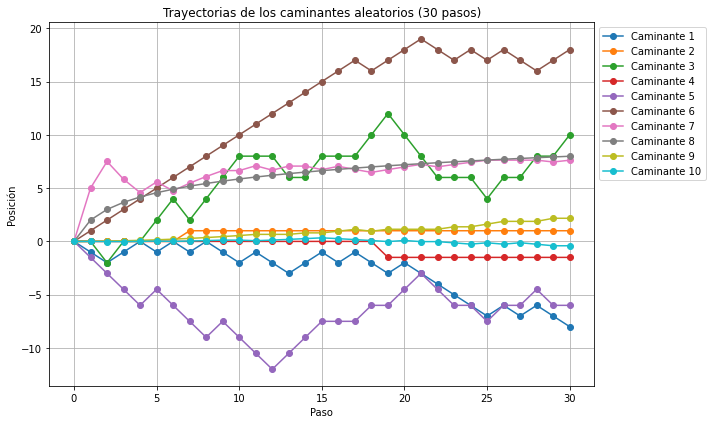

In [191]:
import random
import matplotlib.pyplot as plt

def simular_caminata(parametros, pasos=30):
    """
    parámetros: función que dada la iteración i devuelve (p, q, r)
    pasos: cantidad de pasos a simular.
    Retorna una lista con la posición en cada paso (incluyendo el inicio en 0).
    """
    posiciones = [0]
    pos = 0
    for i in range(1, pasos + 1):
        p, q, r = parametros(i)
        # Validamos que p+q no exceda 1
        if p + q > 1:
            raise ValueError(f"La suma de p y q es mayor que 1 en el paso {i}.")
        rnd = random.random()
        if rnd < p:
            pos += r
        elif rnd < p + q:
            pos -= r
        posiciones.append(pos)
    return posiciones

# Definición de funciones para cada caminante:

# Caminante 1: p = q = 0.5, r = 1 (constantes)
def caminante1(i):
    return 0.5, 0.5, 1

# Caminante 2: p = 0.05, q = 0.01, r = 1
def caminante2(i):
    return 0.05, 0.01, 1

# Caminante 3: p = 0.3, q = 0.3, r = 2
def caminante3(i):
    return 0.3, 0.3, 2

# Caminante 4: p = 0.05, q = 0.02, r = 1.5
def caminante4(i):
    return 0.05, 0.02, 1.5

# Caminante 5: p = 0.45, q = 0.44, r = 1.5
def caminante5(i):
    return 0.45, 0.44, 1.5

# Caminante 6: p = min{1, 12/i}, q = 1-p, r = 1
def caminante6(i):
    p = min(1, 12/i)
    q = 1 - p
    return p, q, 1

# Caminante 7: p = 0.5, q = 0.3, r = 5/i
def caminante7(i):
    return 0.5, 0.3, 5/i

# Caminante 8: p = 1, q = 0, r = 2/i
def caminante8(i):
    return 1, 0, 2/i

# Caminante 9: p = min{1, 10/i}, q = min{1-p, 0.05}, r = 0.01*i
def caminante9(i):
    p = min(1, 10/i)
    q = min(1 - p, 0.05)
    return p, q, 0.01 * i

# Caminante 10: p = 0.45, q = 0.45, r = 0.005*i
def caminante10(i):
    return 0.45, 0.45, 0.005 * i

# Lista de funciones de los caminantes
caminantes = [caminante1, caminante2, caminante3, caminante4, caminante5,
              caminante6, caminante7, caminante8, caminante9, caminante10]

resultados = []
trayectorias = []

# Simulación de cada caminante
for idx, caminante in enumerate(caminantes, start=1):
    posiciones = simular_caminata(caminante, pasos=30)
    trayectorias.append(posiciones)
    pos_final = posiciones[-1]
    resultados.append((idx, pos_final))
    print(f"Caminante {idx}: posición final = {pos_final:.4f}")

# Determinar cuál llega más lejos (mayor posición final)
mejor = max(resultados, key=lambda x: x[1])
print("\nEl caminante que llega más lejos es el Caminante", mejor[0],
      "con posición final =", f"{mejor[1]:.4f}")

# Graficar las trayectorias
plt.figure(figsize=(10, 6))
for idx, posiciones in enumerate(trayectorias, start=1):
    plt.plot(range(0, 31), posiciones, marker='o', label=f'Caminante {idx}')
plt.xlabel('Paso')
plt.ylabel('Posición')
plt.title('Trayectorias de los caminantes aleatorios (30 pasos)')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(True)
plt.tight_layout()
plt.show()


El caminante que llegó más lejos es el número 6 con una distancia de 8.00.


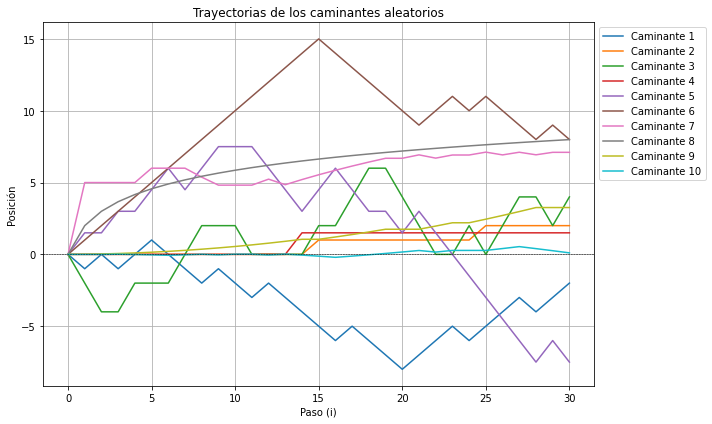

In [206]:
import random
import matplotlib.pyplot as plt

def walker1(i):
    p = 0.5
    q = 0.5
    r = 1
    return p, q, r

def walker2(i):
    p = 0.05
    q = 0.01
    r = 1
    return p, q, r

def walker3(i):
    p = 0.3
    q = 0.3
    r = 2
    return p, q, r

def walker4(i):
    p = 0.05
    q = 0.02
    r = 1.5
    return p, q, r

def walker5(i):
    p = 0.45
    q = 0.44
    r = 1.5
    return p, q, r

def walker6(i):
    p = min(1.0, 12.0 / i)
    q = 1.0 - p
    r = 1
    return p, q, r

def walker7(i):
    p = 0.5
    q = 0.3
    r = 5.0 / i
    return p, q, r

def walker8(i):
    p = 1.0
    q = 0.0
    r = 2.0 / i
    return p, q, r

def walker9(i):
    p = min(1.0, 10.0 / i)
    q = min(1.0 - p, 0.05)
    r = 0.01 * i
    return p, q, r

def walker10(i):
    p = 0.45
    q = 0.45
    r = 0.005 * i
    return p, q, r

# Lista de todos los caminantes
walkers = [walker1, walker2, walker3, walker4, walker5,
           walker6, walker7, walker8, walker9, walker10]

# Simulación de cada caminante
results = []
positions_over_time = []  # Para almacenar las posiciones en cada paso
for idx, walker in enumerate(walkers):
    position = 0.0
    positions = [0.0]  # Inicia en la posición 0
    for step in range(1, 31):  # Pasos del 1 al 30
        i = step
        p, q, r = walker(i)
        rand = random.random()
        if rand < p:
            position += r
        elif rand < p + q:
            position -= r
        positions.append(position)  # Guardar la posición en cada paso
    positions_over_time.append(positions)  # Guardar las posiciones del caminante
    results.append((idx + 1, position))  # Guardar número del caminante y posición final

# Determinar el caminante más lejano
max_distance = -float('inf')
winner = None
for walker_num, pos in results:
    current_distance = abs(pos)
    if current_distance > max_distance:
        max_distance = current_distance
        winner = walker_num

print(f"El caminante que llegó más lejos es el número {winner} con una distancia de {max_distance:.2f}.")

# Graficar las trayectorias de los caminantes
plt.figure(figsize=(10, 6))
for idx, positions in enumerate(positions_over_time):
    plt.plot(range(31), positions, label=f'Caminante {idx + 1}')

plt.title("Trayectorias de los caminantes aleatorios")
plt.xlabel("Paso (i)")
plt.ylabel("Posición")
plt.axhline(0, color='black', linestyle='--', linewidth=0.5)  # Línea en y=0
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))  # Leyenda fuera del gráfico
plt.grid(True)
plt.tight_layout()
plt.show()